PCA / ZCA Whitening:  
    * http://ufldl.stanford.edu/tutorial/unsupervised/PCAWhitening/
    * https://stats.stackexchange.com/questions/117427/what-is-the-difference-between-zca-whitening-and-pca-whitening
    
Factor Analysis:
* https://www.analyticsvidhya.com/blog/2015/11/8-ways-deal-continuous-variables-predictive-modeling/

Things to try
PCA / ZCA Whitening:  http://ufldl.stanford.edu/tutorial/unsupervised/PCAWhitening/

# Load Necessary Tools
Vizualization References
[Pandas](http://pandas.pydata.org/pandas-docs/stable/visualization.html),
[Seaborn](https://seaborn.pydata.org/)

In [11]:
# Ensure Cuda is in Path
# !echo $PATH

# Reload fcns
import importlib
import churn_utilities
import churn_io
import model_utilities
importlib.reload(churn_utilities)
importlib.reload(churn_io)
importlib.reload(model_utilities)
from churn_utilities import *
from churn_io import *
from model_utilities import *

# Initialize Run Tracker
RUN=1
# Data Sci 
import pandas as pd
import numpy as np
from sklearn import metrics # roc_curve, roc_auc_score, auc, average_precision_score
from scipy.stats import boxcox
import tensorflow as tf
# OS
from subprocess import call
# Viz
%matplotlib inline
import matplotlib
matplotlib.style.use('ggplot')
from matplotlib import pyplot as plt
from pandas.tools.plotting import scatter_matrix
import time

# Import Data, Define Additional Vars

In [3]:
# Only run this cell if necessary
new_data_necessary=False
if new_data_necessary:
    print("It's Necessary!")
    df = churn_io.from_redshift()
    data = churn_io.split_data(df)
    churn_io.split_data_to_file(data)

It's Necessary!


In [2]:
load_raw_necessary=1
if load_raw_necessary:
    print("Raw!")
    x_train_raw, y_train, x_valid_raw, y_valid, x_test_raw, y_test = churn_io.split_data_from_file()

Raw!


In [9]:
# WRITING fcn-TRANSFORMED DATA to FILE
box_necessary=False
if box_necessary:
    print("Boxing!")
    x_train_box, x_valid_box, x_test_box = condition_data(x_train_raw, x_valid_raw, x_test_raw, trans="box", threshold=5, verbose=False)
    print("Tranform Complete!")
    churn_io.split_data_to_file((x_train_box, x_valid_box, x_test_box), prefix="box_")

log_necessary=False
if log_necessary:
    print("\nLogging!")
    x_train_log, x_valid_log, x_test_log = condition_data(x_train_raw, x_valid_raw, x_test_raw, trans="log", threshold=5, verbose=False)
    print("Tranform Complete!")
    churn_io.split_data_to_file((x_train_log, x_valid_log, x_test_log), prefix="log_")

rec_necessary=False
if rec_necessary:
    print("\nReciprocating!")
    x_train_rec, x_valid_rec, x_test_rec = condition_data(x_train_raw, x_valid_raw, x_test_raw, trans="rec", threshold=5, verbose=False)
    print("Tranform Complete!")
    churn_io.split_data_to_file((x_train_rec, x_valid_rec, x_test_rec), prefix="rec_")
    

print("\nImport Transformed Data and Rescale")
# restore data
restore=False
if restore:
    print("Restoring X...")
    x_train = churn_io.from_file("box_x_train")
    x_valid = churn_io.from_file("box_x_valid")
    x_test = churn_io.from_file("box_x_test")
    # Y (Always the Same)
    print("Restoring Y...")
    y_train = churn_io.from_file("y_train")
    y_valid = churn_io.from_file("y_valid")
    y_test = churn_io.from_file("y_test")

rescale_necessary=True
if rescale_necessary:
    print("\nBegin Rescaling...\n")
    x_train, x_valid, x_test = rescale_data(x_train, x_valid, x_test, fnorm="fn11", threshold=2, bins=True, verbose=False)
    print("Scaling Complete!")


Import Transformed Data and Rescale

Begin Rescaling...

Scaling Complete!


# Checkpoint

In [12]:
x_train, y_train, x_valid, y_valid, x_test, y_test = churn_io.split_data_from_file(prefix="box_")

### What are we working with?

X Training:    (n_instances, n_features) =  (569283, 72)
X Validation:  (n_instances, n_features) =  (160111, 72)
X Test:        (n_instances, n_features) =  (160111, 72)
Data Type:  float32
Min: 0.0 Mean: 0.393618 Max: 1.22799


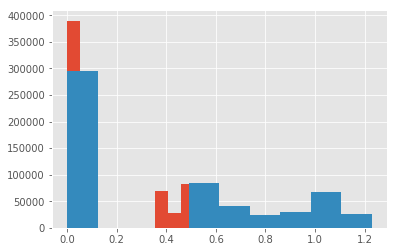

In [13]:
#x_train, y_train, x_valid, y_valid, x_test, y_test = churn_transform(raw_data)n_classes = raw_data['n_classes']
print('X Training:    (n_instances, n_features) = ', x_train.shape)
print('X Validation:  (n_instances, n_features) = ', x_valid.shape)
print('X Test:        (n_instances, n_features) = ', x_test.shape)
print('Data Type: ', x_train['nxt_view_ep_lst_90days'].dtype)
print('Min:', x_train.loc[:,'nxt_view_ep_lst_90days'].min(), 'Mean:', x_train.loc[:,'nxt_view_ep_lst_90days'].mean(), 'Max:', x_train.loc[:,'nxt_view_ep_lst_90days'].max())
x_train.loc[:,'nxt_view_ep_lst_30days'].hist()
x_train.loc[:,'nxt_view_ep_lst_90days'].hist()

In [14]:
# x_train.isnull().sum()  # shows how many nulls in each feature
# x_train.isnull().sum().sum()   # how many nulls overall
# For whatever reason, there are only 2 -- both in vod_acc... so just fillnana
x_train = x_train.fillna(0)
x_valid = x_valid.fillna(0)
x_test  = x_test.fillna(0)

#### Class Imbalance...
Might I have a class imbalance problem?!
https://aqibsaeed.github.io/2016-08-10-logistic-regression-tf/

#### Some Helpful TF Pages
http://learningtensorflow.com/index.html

## TensorBoard
* Good for the hyperparameter search

```python
# Try a few learning rates
for learning_rate in [1e-1,5e-2,1e-2,5e-3]:
    # Play w/ varying number of hidden layers
    for use_sig_hl_w_7_nodes in [True, False]:
        for use_tanh_hl_w_7_nodes in [True, False]:
            # Construct a unique hyperparameter string for each run
            hparam_str = mk_hparm_str(learning_rate, use_sig_hl_w_7_nodes, use_tanh_hl_w_7_nodes)
            writer = tf.summary.FileWriter(logsDir + hparam_str)
            # Run Model w/ new settings
            churn_model(learning_rate, use_sig_hl_w_7_nodes, use_tanh_hl_w_7_nodes)
            # To see all runs in TensorBoard, point TB at parent directory (logs)
```

TensorBoard has a very useful feature: the embedding visualizer.  It allows you take very high-dim
data and project it onto 2 or 3 dims using PCA or t-SNE.  (See tutorial on TF website.)

In [15]:

# Feature Sets
# Note on B4:  I formerly defined the B4 vars as the answer to the
#   question, "Is this B4 event w/in next 30 days?"  However, I realized
#   that's a better "winback question."  The relevant "churn question" is,
#   "Was this B4 event w/in the past 30 days?"

#singles
nvl    = ['num_vol_losses']
ppd    = ['pmt_pct_days_paid']
ppv    = ['pct_ppv1']
nif    = ['num_invol_fail']
nv90d  = ['no_view_90days_flag']
vod30d = ['vod_lst_30days']
nxt90d = ['nxt_view_ep_lst_90days']

everything = list(x_train.drop(['as_on_dt','cust_guid'],axis=1).columns)

exl    = ['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 'num_invol_fail', 
          'vod_lst_30days', 'nxt_view_ep_lst_90days', 'no_view_90days_flag']

exl6    = ['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 
          'vod_lst_30days', 'nxt_view_ep_lst_90days', 'no_view_90days_flag']
exl5    = ['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 
           'nxt_view_ep_lst_90days', 'no_view_90days_flag']

b4 = ['rumble30','mania30','slam30','survivor30']

# Time
months = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
months11 = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov'] # reduces collinearity
weeks = ['week'+'{:02d}'.format(num+1) for num in range(52)]
fortnights = ['fortnight'+'{:02d}'.format(num+1) for num in range(26)]
fortnights25 = ['fortnight'+'{:02d}'.format(num+1) for num in range(25)]  # reduces collinearity


# EXL + Time
exl_b4 = exl + b4
exl_months = exl + months
exl_weeks = exl + weeks
exl_fortnights = exl+fortnights
exl_b4_months = exl + b4 + months


# NXT Mods
exl_no_nxt   = nvl+ppd+ppv+nif+nv90d+vod30d
exl_nxtmod1  = exl_no_nxt+['pt_nxt_v1']
exl_nxtmod2  = exl_no_nxt+['pt_nxt_v1','pt_nxt_v2']
exl_nxtmod3  = exl_no_nxt+['pt_nxt_a']
exl_nxtmod4  = exl_no_nxt+['pt_nxt_anorm']
exl_nxtmod5  = exl_no_nxt+['pt_nxt_a','pt_nxt_v1']
exl_nxtmod6  = exl_no_nxt+['nxt_view_ep_lst_30days']
exl_nxtmod7  = exl_no_nxt+['nxt_view_ep_lst_30days', 'nxt_lst_30to60days', 'nxt_lst_60to90days']
exl_nxtmod8  = exl_no_nxt+['nxt_v1']
exl_nxtmod9  = exl_no_nxt+['nxt_v1','nxt_v2']
exl_nxtmod10 = exl_no_nxt+['nxt_acc']
exl_nxtmod11 = exl + ['nxt_v1']
exl_nxtmod12 = exl_no_nxt + ['nxt_view_ep_lst_30days','nxt_lst_30to60days','nxt_lst_60to90days','nxt_v1','nxt_v2','nxt_acc']
exl_nxtmod13 = exl_no_nxt + ['nxt_view_ep_lst_30days','nxt_lst_30to60days','nxt_lst_60to90days']
exl_nxtmod14 = exl_no_nxt + ['nxt_v1','nxt_v2']
exl_nxtmod15 = exl + ['nxt_v1','nxt_v2']
exl_nxtmod16 = exl + ['nxt_acc']
# Exl_NxtMod13 might be best...
exl_mod = exl_no_nxt + months + ['nxt_view_ep_lst_30days','nxt_lst_30to60days','nxt_lst_60to90days']

# 2017-05-02:  NXT (Final)
nxt = ['nxt_view_ep_lst_30days','nxt_lst_30to60days','nxt_lst_60to90days']

# Vod Mods
exl_no_vod   = nvl+ppd+ppv+nif+nv90d+nxt
vod_pos1 = exl_no_vod + ['vod_lst_30days','vod_lst_30to60days']
vod_pos2 = exl_no_vod + ['vod_lst_30days','vod_lst_30to60days','vod_lst_60to90days']
vod_vel1 = exl_no_vod + ['vod_v1']
vod_vel2 = exl_no_vod + ['vod_v1', 'vod_v2']
vod_acc  = exl_no_vod + ['vod_acc']

###
vod_pos = ['vod_lst_30days','vod_lst_30to60days','vod_lst_60to90days']
nxt_pos = ['nxt_view_ep_lst_30days','nxt_lst_30to60days','nxt_lst_60to90days']
new = exl5 + vod_pos + nxt_pos + months

# Doubles
ppd_and_ppv = ppd + ppv
ppd_nvl     = ppd + nvl
ppv_nvl     = ppv + nvl
ppd_ppv_nvl = ppd + ppv + nvl
top3_B4     = ppd_ppv_nvl + b4

rebuf306090=['avg_rebuf_ratio_lst_30days','avg_rebuf_ratio_lst_60days', 'avg_rebuf_ratio_lst_90days']


In [34]:
#==============================================
# Choose x_cols
#==============================================
features = exl_b4

xx_train = x_train.loc[:, features].values
xx_valid = x_valid.loc[:, features].values
xx_test  = x_test.loc[:,  features].values
if str(type(y_train)) != "<class 'numpy.ndarray'>":
    y_train = y_train.values
    y_valid = y_valid.values
    y_test = y_test.values


# Data Shape
n_train = xx_train.shape[0]
n_valid = xx_valid.shape[0]
n_test  = xx_test.shape[0]
n_data_tot = n_train + n_valid + n_test
n_data_train = xx_train.shape[0]
n_features = xx_train.shape[1]
n_classes  = y_train.shape[1]
    

print('Chosen Inputs: ', x_train.loc[:, features].columns, '\n')
print('Event: ', 'CHURN')  # y_cols deleted at one pont...
print('Num Classes: ', n_classes)
print('X Shape: ', xx_train.shape)



#-----------------------------------------------------
# Create Logs for TensorBoard
#-----------------------------------------------------
dirname = time.strftime("%Y-%m-%d")
subdir = "0_testing_code_2"
if subdir == "": 
    subdir = str(RUN)
    RUN+=1

model_dir = "logs/"+dirname+"/"+subdir
call(["mkdir", "-p" + model_dir])  # only makes dir if does not exist
print("logs/"+model_dir)
writer = tf.summary.FileWriter(model_dir)
NOTE = "Testing discretization and new code... Several layers..."
#call(["echo", NOTE+" > logs/"+dirname+"/"+subdir+"/README.txt"])
with open(model_dir+"/README.txt", "w") as text_file:
    print("NOTE:\n{}".format(NOTE), file=text_file)
# In Another Terminal:
#!if [ `ps | grep -ic tensor` -eq 0 ]; then echo "TensorBoard already running..."; tensorboard --logdir ./logs &; open http://10.24.5.85:6006; else echo "Starting TensorBoard..."; fi
#!if [ `ps | grep -ic tensor` -eq 0 ]; then tensorboard --logdir ./logs; else echo 'Starting TensorBoard...'; fi
# Background processes not supported...
# os.mkdir... os.rmdir

Chosen Inputs:  Index(['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 'num_invol_fail',
       'vod_lst_30days', 'nxt_view_ep_lst_90days', 'no_view_90days_flag',
       'rumble30', 'mania30', 'slam30', 'survivor30'],
      dtype='object') 

Event:  CHURN
Num Classes:  1
X Shape:  (569283, 11)
logs/logs/2017-06-06/0_testing_code_2


In [17]:
w=get_weights(7,2,[5,7])
b=get_biases(7,2,[5,7])
l=['cat','dog','fish']
for ww,bb,ll in zip(w,b,l): print(ll)

cat
dog
fish


In [31]:
# Sometimes necessary:
# sess.close()

#-----------------------------------------------------
# Session Parameters
#-----------------------------------------------------
learning_rate = 0.1
epochs = 15
batch_size=30000
display_step = 1
kp=1.0
l2_reg_penalty=0.5
one_hot=False


# Just in case...
tf.reset_default_graph()


    
#-----------------------------------------------------
# Input Data Placeholders
#-----------------------------------------------------
#  -- None: 
#     [None, n_features] and [None, n_classes] denotes that
#     we are not specifying how many instances will be used
#     for any given training session or data batch.
####
## need to set x_feed to (None,n_features) after experimentation
#x_feed = tf.placeholder(shape=(None,1), dtype=tf.float32)
#with tf.name_scope("inputs"):
keep_prob = tf.placeholder(tf.float32)
x_feed = tf.placeholder(shape=(None,n_features), dtype=tf.float32, name="Features")
if one_hot:
    yy_train = np.squeeze(np.array([y_train, 1-y_train]).T)
    yy_valid = np.squeeze(np.array([y_valid, 1-y_valid]).T)
    yy_test = np.squeeze(np.array([y_test,   1-y_test]).T)
    y_feed = tf.placeholder(shape=(None,n_classes+1), dtype=tf.float32, name="Labels")
    n_labels=2
else:
    yy_train = y_train
    yy_valid = y_valid
    yy_test = y_test
    y_feed = tf.placeholder(shape=(None,n_classes), dtype=tf.float32, name="Labels")
    n_labels=1


#-----------------------------------------------------
# Construct model
#-----------------------------------------------------
#  -- to construct a simple logistic regression, 
#     construct a simple linear regression and  
#     compute its sigmoid
#  -- to construct a multiple logistic regression,
#     construct a multiple linear regression and
#     compute its softmax
with tf.name_scope("model"):
    y_model = x_feed
    y_model,w1,b1 = fully_conn(y_model, 33, keep_prob, activation='relu', seed=3, name="fc2")
    y_model,w2,b2 = fully_conn(y_model, 33, keep_prob, activation='relu', seed=3, name="fc3")
    y_model,w3,b3 = fully_conn(y_model, 1, keep_prob, activation='softmax', seed=5, name="output")
    
    #wb_list = [w1,b1,w2,b2,w3,b3]
    #weights = get_weights(n_features,n_labels,[5,3])
    #biases = get_biases(n_features,n_labels,[5,3])
    #y_model = multilayer_perceptron(x_feed, weights,biases)



#-----------------------------------------------------
# Choose a Learning Method:  Loss Fcn & Optimizer
#-----------------------------------------------------
with tf.name_scope("cost"):
    #loss="cross", mean="sum" produces nans...so no cross-entropy for now...
    #loss = getLost(y_model, y_feed, loss="squared")
    #cost = getCost(loss, cost="mean")
    #cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=y_model, labels=y_feed))
    #cost = tf.reduce_mean(-tf.reduce_sum(y_feed*tf.log(y_model), axis=1))
    cost = tf.reduce_mean(tf.sqrt(tf.nn.l2_loss(y_feed-y_model)))
    #cost = tf.reduce_mean(tf.nn.log_poisson_loss(y_model, y_feed))
    
    #
    #unregularized_loss = tf.nn.l2_loss(y_feed-y_model)
    #l2_regularizer = l2_reg_penalty * sum([tf.nn.l2_loss(wb) for wb in wb_list])
    #loss = tf.add(unregularized_loss,l2_regularizer, name="loss")
    #cost = tf.reduce_mean(loss)
    #
    #cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=y_model, labels=y_feed))

with tf.name_scope("optimizer"):
    optimizer = getOpt(learning_rate, opt="Adam")
    train = optimizer.minimize(cost)

with tf.name_scope('Accuracy'):
    acc = tf.equal(tf.argmax(y_model, 1), tf.argmax(y_feed, 1))
    acc = tf.reduce_mean(tf.cast(acc, tf.float32))

# New Stuff (2017-04-24)  ((NOT FULLY IMPLEMENTED))
#accuracy, update_op_acc = tf.contrib.metrics.streaming_accuracy(
#    y_feed, y_model)
#error, update_op_error = tf.contrib.metrics.streaming_mean_absolute_error(
#    y_feed, y_model)



In [32]:
#-----------------------------------------------------
# TensorBoard Graph and Summaries
#-----------------------------------------------------
# Create a summary to monitor cost tensor
tf.summary.scalar("loss", cost)
# Create a summary to monitor accuracy tensor
tf.summary.scalar("accuracy", acc)
# Merge all summaries into a single op
merged_summary_op = tf.summary.merge_all()

#-----------------------------------------------------
# **Graph Execution / Training
#-----------------------------------------------------
param_updates = []
#param_updates = np.empty(shape=[1],dtype=float)
saver=tf.train.Saver()


## Execute TensorFlow Session

In [33]:
# in separate cell in case you want to continue training
#with tf.device('/gpu:0'):
restore=False
#initialize=False
with tf.Session() as sess:
    
    #-----------------------------------------------------
    # Initialize or Restore Session?
    #-----------------------------------------------------
    if restore == False: 
        init = tf.global_variables_initializer()
        sess.run(init)
        writer.add_graph(sess.graph)
    else:
        # Restore variables from disk.
        # https://www.tensorflow.org/programmers_guide/variables
        saver.restore(sess, model_dir + "/model.ckpt")
        print("Model restored from "+ model_dir)
        
    
    #-----------------------------------------------------
    # Train
    #-----------------------------------------------------
    for i in range(epochs):
        avg_loss = 0.0
        total_batch = int(xx_train.shape[0]/batch_size)
    
        for j in range(total_batch):
            bx = xx_train[i*batch_size:(i+1)*batch_size]
            # Old Way
            #evals = sess.run([train, loss], feed_dict={y_feed: yy_train, x_feed: xx_train})[1:]
            #avg_loss += evals[2]/total_batch
            # W/ fully_conn
            _, evals, summary = sess.run([train, cost, merged_summary_op], 
                                         feed_dict={y_feed: yy_train, x_feed: xx_train, keep_prob: kp})
            
            # Write logs at every iteration
            writer.add_summary(summary, i * total_batch + j)
            # Compute average loss
            avg_loss += evals/total_batch
        
            # New Stuff (2017-04-24)
            #sess.run([update_op_acc, update_op_error], feed_dict={y_feed: yy_train, x_feed: xx_train})
    
        if i % display_step == 0:
            #_w = evals[0][0,0]  # for simpLogReg
            #_w = evals[0][0,0]  # for multLogReg
            #_b = evals[1][0]
            #_l = evals[2]
            _l = evals
            print('Epoch: ','%04d' % (i+1))#, '  Weight: ','{:.9f}'.format(_w),'  Bias: ','{:.9f}'.format(_b))
            print('    EndLoss: ', '{:.9f}'.format(_l),'  AvgLoss: ', 
                  '{:.9f}'.format(avg_loss))
            print(' ')
            param_updates.append(evals)
        
            # New Stuff (2017-04-24)
            #accuracy, mean_absolute_error = sess.run([accuracy, mean_absolute_error], 
            #                                         feed_dict={y_feed: y_train, x_feed: xx_train})
            #print('Accuracy:', accuracy, 'MAE:', mean_absolute_error)

    print('Training Complete!\n')
    

    #---------------------------------------------------
    # Save the variables to disk.
    #---------------------------------------------------
    save_path = saver.save(sess, model_dir + "/model.ckpt")
    print('----------------------------------------------------')
    print("Model saved in file: %s" % save_path)
    print(" * To continue training, simply do not set 'initialize' to True.")  
    print(" * To permanently save this ckpt, move from /tmp before next run.\n")

    print('----------------------------------------------------')
    print("To run TensorBoard:\n" \
            "--> tensorboard --logdir=/tmp/tensorflow_logs " \
            "\nThen open http://0.0.0.0:6006/ into your web browser")

Epoch:  0001
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 
Epoch:  0002
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 
Epoch:  0003
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 
Epoch:  0004
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 
Epoch:  0005
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 
Epoch:  0006
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 
Epoch:  0007
    EndLoss:  514.378295898   AvgLoss:  514.378295898
 


KeyboardInterrupt: 

In [371]:
y_actual.shape

(160111,)

## Scores

In [30]:
#-----------------------------------------------------
# Close TF Session
#-----------------------------------------------------
#sess.close()

# fpr, tpr, threshold = metrics.roc_curve(y_valid, y_pred, pos_label=1)
# auc = metrics.auc(fpr,tpr)
thresh=0.5
y_set = 'Valid'  # 'valid' or 'test'
with tf.Session() as sess:
    
    
    # Restore variables from disk.
    # https://www.tensorflow.org/programmers_guide/variables
    saver.restore(sess, model_dir + "/model.ckpt")
    print("Model restored from " + model_dir)
        
    if one_hot:
        y_predv   = sess.run(tf.nn.softmax(y_model), feed_dict = {x_feed: xx_valid, keep_prob: 1.0})
        y_predt   = sess.run(tf.nn.softmax(y_model), feed_dict = {x_feed: xx_valid, keep_prob: 1.0})
    else:
        y_predv   = sess.run(y_model, feed_dict = {x_feed: xx_valid, keep_prob: 1.0})
        y_predt   = sess.run(y_model, feed_dict = {x_feed: xx_valid, keep_prob: 1.0})
    
    
    if y_set=='Valid': 
        y_actual = yy_valid[:,0]
        y_pred = y_predv[:,0]
        y_class = np.array(y_pred > thresh, dtype=np.float32)
    else:
        y_actual = yy_test
        y_pred   = y_predt
        y_class = np.array(y_pred > thresh, dtype=np.float32)


    print('| RO-AUC    | ',round(100*metrics.roc_auc_score(y_actual, y_pred),1), ' | ')
    
    # Precision: 
    #  -- precision is the ability of the classifier not to label a negative sample as positive
    #  -- precision = tp / (tp+fp)
    print('| Precision | ',round(100*metrics.precision_score(y_actual, y_class),1), ' | ')

    # Recall: 
    #  -- recall is the ability of the classifier to find all the positive samples
    print('| Recall    | ', round(100*metrics.recall_score(y_actual, y_class),1), ' | ')

    # Average Precision: Area under the Precision-Recall curve
    #  -- precision = tp / (tp+fp)
    #  -- recall = tp / (tp+fn)
    print('| PR-AUC    | ',round(100*metrics.average_precision_score(y_actual, y_pred),1), ' | ')

    # F1 Score
    #  -- must binarize y_pred (e.g., what threshold is roc_auc_score using?)
    #  -- f1 = harmonic_mean(precision, recall) = 2pr/(p+r)
    #  -- y_class = ...
    print('| F1 Score  | ',round(100*metrics.f1_score(y_actual, y_class),1), ' | ')

    # R2 Score
    #  -- must binarize y_pred (e.g., what threshold is roc_auc_score using?)
    #  -- f1 = harmonic_mean(precision, recall) = 2pr/(p+r)
    #  -- y_class = ...
    print('| R2 Score  | ',round(100*metrics.r2_score(y_actual, y_pred),1), ' | ')
    
    # Accuracy: Is this model a good "shot caller"?
    #   -- must binarize y_pred, (e.g., what threshold is roc_auc_score using?)
    #  -- y_class = ...
    print('| Accuracy  | ',round(100*metrics.accuracy_score(y_actual, y_class, normalize=True),1), ' | ')

    print('| MnAbsErr  | ',round(100*metrics.mean_absolute_error(y_actual, y_pred),1), ' | ')
    print('| MnSqErr   | ',round(100*metrics.mean_squared_error(y_actual, y_pred),1), ' | ')
    print('| MedAbsErr | ',round(100*metrics.median_absolute_error(y_actual, y_pred),1), ' | ')

INFO:tensorflow:Restoring parameters from logs/2017-06-06/0_testing_code_2/model.ckpt
Model restored from logs/2017-06-06/0_testing_code_2
| RO-AUC    |  50.0  | 
| Precision |  7.1  | 
| Recall    |  100.0  | 
| PR-AUC    |  53.6  | 
| F1 Score  |  13.3  | 
| R2 Score  |  -1299.4  | 
| Accuracy  |  7.1  | 
| MnAbsErr  |  92.9  | 
| MnSqErr   |  92.9  | 
| MedAbsErr |  100.0  | 


In [116]:
# Close session or keep going?  ...don't really need anymore since I'm using contexts
#sess.close()
# pd.DataFrame(y_pred).isnull().sum()
y_pred.max()
y_pred

array([[-2.95422077],
       [-3.81779289],
       [-2.29214025],
       ..., 
       [-2.48729253],
       [-4.14883184],
       [-1.72494316]], dtype=float32)

## Gain plots Dave wants

1.  Order (y_pred, churn=y_valid (or y_test)) by y_pred
2.  Break into deciles 
3.  For each decile:
    - record exact population size
    - record number of churners
    - compute churn rate (churners/popSize)
    - compute % of all churners (theseChurners/allChurners)
    - compute cumaltive % of churners
    - show what cumalative % of churners would be if groups were randomly selected from general population

Can also record number of predicted churners...

In [187]:
# 0. Choose y_valid or y_test

# UPDATE: 2017-05-04:
#   -- new code means that we have to restore ckpt model data before this...
#   -- doing other stuff now / update this section later

y_set = 'Valid'  # 'valid' or 'test'
if y_set=='Valid': 
    y_actual = yy_valid
    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_valid})
else:
    y_actual = yy_test
    y_pred   = sess.run(y_model, feed_dict = {x_feed: xx_test})


# 1. Order (y_pred, churn=y_valid (or y_test)) by y_pred
sortIndex      =  np.argsort(y_pred[:,0])
sortIndex      =  sortIndex[::-1]
y_pred_sorted  =  y_pred[sortIndex,0]
y_sorted       =  y_actual[sortIndex,0]

# 2. Break y_pred and churn arrays into deciles 
#    -- since arrays are same length, np.array_split() splits them
#       into same-sized groups (all equal if possible)
y_pred_deciles = np.array_split(y_pred_sorted, 10)
y_deciles      = np.array_split(y_sorted, 10)


# 3. Record decile properties 
# - Population size for each decile
decile = np.linspace(1,10,10)
decile_size = np.array([len(decile) 
                        for decile in y_pred_deciles])
# - Number of actual churners in each decile
num_churners = np.array([sum(decile) 
                         for decile in y_deciles])
# - Churn Rate (churners/popSize)
churn_rate = np.array([round(100*n_churn/decile_size[i],1)
                       for i,n_churn in enumerate(num_churners)])
# - Number of All Churners
all_churners = np.repeat(np.sum(num_churners), 10)
# - Decile's Churner Stock:  num_churners / all_churners
proportion_of_churn = np.array([round(100*n_churn/all_churners[0],2) 
                          for n_churn in num_churners])
# - Cumulative sum of Churner Stock
cum_prop = np.cumsum(proportion_of_churn)
# - Cumulative sum of Churner Stock if Deciles were randomized groups
cum_control = np.linspace(10,100,10)

# Generate Pandas DataFrame
churnTable = pd.DataFrame({
    'decile': decile,
    'size': decile_size,
    'num_churn': num_churners,
    'churn_rate': churn_rate,
    'all_churn': all_churners,
    'proportion_of_churn': proportion_of_churn,
    'cum_prop': cum_prop,
    'cum_control': cum_control
})
churnTable=churnTable[['decile','size','num_churn','churn_rate','all_churn','proportion_of_churn','cum_prop','cum_control']]

In [158]:
#plt.plot(y_pred[indices,0])
#fileName='name'
#churnTable.to_csv('Model-Data/'+fileName+'.csv')
churnTable

,decile,size,num_churn,churn_rate,all_churn,proportion_of_churn,cum_prop,cum_control
0,1.0,16012,3869.0,24.2,11350.0,34.09,34.09,10.0
1,2.0,16011,1813.0,11.3,11350.0,15.97,50.06,20.0
2,3.0,16011,1318.0,8.2,11350.0,11.61,61.67,30.0
3,4.0,16011,1077.0,6.7,11350.0,9.49,71.16,40.0
4,5.0,16011,886.0,5.5,11350.0,7.81,78.97,50.0
5,6.0,16011,764.0,4.8,11350.0,6.73,85.70,60.0
6,7.0,16011,578.0,3.6,11350.0,5.09,90.79,70.0
7,8.0,16011,455.0,2.8,11350.0,4.01,94.80,80.0
8,9.0,16011,343.0,2.1,11350.0,3.02,97.82,90.0
9,10.0,16011,247.0,1.5,11350.0,2.18,100.00,100.0


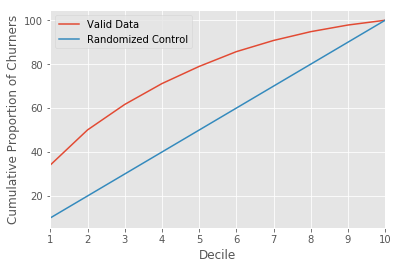

In [159]:
#plt.plot(churnTable['cum_stock'])
#plt.plot(churnTable['cum_stock_control'])
#churnTable['cum_prop'].plot()
#churnTable['cum_control'].plot()
fig = churnTable.plot(x='decile',y=['cum_prop','cum_control'])
fig.set_xlabel('Decile')
fig.set_ylabel('Cumulative Proportion of Churners')
fig.legend(labels=[y_set+' Data', 'Randomized Control'])

In [134]:
path2fig  = "/path/to/project/Figures/"
fileName = time.strftime("%Y-%m-%d") + "__19nsig-1nsig_lr005-bs250-ep7_BoxExl+M_Test"
fig.get_figure().savefig(path2fig+fileName+".png")


In [135]:
# Save Training Checkpoint?
path2ckpt = "/path/to/project/Model-Ckpt/"
saver.save(sess,path2ckpt+fileName)

In [160]:
#-----------------------------------------------------
# Close TF Session (if you haven't already!)
#-----------------------------------------------------
sess.close()


In [682]:
path2ckpt+fileName

In [179]:
import os
os.getcwd()

## To Restore a Saved Model...

In [183]:
# This actually didn't work for me....
sess = tf.Session()
myModel_meta='Model-Ckpt/2017-04-14__19nsig-1nsig_lr005-bs250-ep7_Exl+M.meta'
new_saver = tf.train.import_meta_graph(myModel_meta)
new_saver.restore(sess, tf.train.latest_checkpoint('./Model-Ckpt/'))
all_vars = tf.get_collection('vars')
for v in all_vars:
    v_ = sess.run(v)
    print(v_)

In [192]:
sess.close()

In [ ]:


if 'num_vol_losses' in dfx.columns: 
    if nlog==True:
        x_train.loc[:,'num_vol_losses'] = np.log(x_train.loc[:,'num_vol_losses']+1)
        x_valid.loc[:,'num_vol_losses'] = np.log(x_valid.loc[:,'num_vol_losses']+1)
        x_test.loc[:,'num_vol_losses']  = np.log(x_test.loc[:,'num_vol_losses']+1)
    if bxcx==True:
        x_train.loc[:,'num_vol_losses'], L_nvl = boxcox(x_train.loc[:,'num_vol_losses']+1)
        x_valid.loc[:,'num_vol_losses']        = boxcox(x_valid.loc[:,'num_vol_losses']+1, L_nvl)
        x_test.loc[:,'num_vol_losses']         = boxcox(x_test.loc[:,'num_vol_losses']+1,  L_nvl)
    f0 = fn11(x_train['num_vol_losses'].copy(),x_valid['num_vol_losses'].copy(),x_test['num_vol_losses'].copy())
    x_train['num_vol_losses'],x_valid['num_vol_losses'],x_test['num_vol_losses'] = f0['train'], f0['val'], f0['test']
    
    
    
if 'pmt_pct_days_paid' in dfx.columns: 
    if nlog==True:
        x_train.loc[:,'pmt_pct_days_paid'] = np.log(x_train.loc[:,'pmt_pct_days_paid']+1)
        x_valid.loc[:,'pmt_pct_days_paid'] = np.log(x_valid.loc[:,'pmt_pct_days_paid']+1)
        x_test.loc[:,'pmt_pct_days_paid']  = np.log(x_test.loc[:,'pmt_pct_days_paid']+1)
    if bxcx==True:
        x_train.loc[:,'pmt_pct_days_paid'], L_ppd = boxcox(x_train.loc[:,'pmt_pct_days_paid']+1)
        x_valid.loc[:,'pmt_pct_days_paid']        = boxcox(x_valid.loc[:,'pmt_pct_days_paid']+1, L_ppd)
        x_test.loc[:,'pmt_pct_days_paid']         = boxcox(x_test.loc[:,'pmt_pct_days_paid']+1,  L_ppd)
    f0 = fn11(x_train['pmt_pct_days_paid'].copy(),x_valid['pmt_pct_days_paid'].copy(),x_test['pmt_pct_days_paid'].copy())
    x_train['pmt_pct_days_paid'],x_valid['pmt_pct_days_paid'],x_test['pmt_pct_days_paid'] = f0['train'], f0['val'], f0['test']
    
    
    
if 'pct_ppv1' in dfx.columns: 
    if nlog==True:
        x_train.loc[:,'pct_ppv1'] = np.log(x_train.loc[:,'pct_ppv1']+1)
        x_valid.loc[:,'pct_ppv1'] = np.log(x_valid.loc[:,'pct_ppv1']+1)
        x_test.loc[:,'pct_ppv1']  = np.log(x_test.loc[:,'pct_ppv1']+1)
    if bxcx==True:
        x_train.loc[:,'pct_ppv1'], L_ppv = boxcox(x_train.loc[:,'pct_ppv1']+1)
        x_valid.loc[:,'pct_ppv1']        = boxcox(x_valid.loc[:,'pct_ppv1']+1, L_ppv)
        x_test.loc[:,'pct_ppv1']         = boxcox(x_test.loc[:,'pct_ppv1']+1,  L_ppv)
    f0 = fn11(x_train['pct_ppv1'].copy(),x_valid['pct_ppv1'].copy(),x_test['pct_ppv1'].copy())
    x_train['pct_ppv1'],x_valid['pct_ppv1'],x_test['pct_ppv1'] = f0['train'], f0['val'], f0['test']
    
    
    
if 'num_invol_fail' in dfx.columns: 
    if nlog==True:
        x_train.loc[:,'num_invol_fail'] = np.log(x_train.loc[:,'num_invol_fail']+1)
        x_valid.loc[:,'num_invol_fail'] = np.log(x_valid.loc[:,'num_invol_fail']+1)
        x_test.loc[:,'num_invol_fail']  = np.log(x_test.loc[:,'num_invol_fail']+1)
    if bxcx==True:
        x_train.loc[:,'num_invol_fail'], L_nif = boxcox(x_train.loc[:,'num_invol_fail']+1)
        x_valid.loc[:,'num_invol_fail']        = boxcox(x_valid.loc[:,'num_invol_fail']+1, L_nif)
        x_test.loc[:,'num_invol_fail']         = boxcox(x_test.loc[:,'num_invol_fail']+1,  L_nif)
    f0 = fn11(x_train['num_invol_fail'].copy(),x_valid['num_invol_fail'].copy(),x_test['num_invol_fail'].copy())
    x_train['num_invol_fail'],x_valid['num_invol_fail'],x_test['num_invol_fail'] = f0['train'], f0['val'], f0['test']
    
    
    
if 'vod_lst_30days' in dfx.columns: 
    if nlog==True:
        x_train.loc[:,'vod_lst_30days'] = np.log(x_train.loc[:,'vod_lst_30days']+1)
        x_valid.loc[:,'vod_lst_30days'] = np.log(x_valid.loc[:,'vod_lst_30days']+1)
        x_test.loc[:,'vod_lst_30days']  = np.log(x_test.loc[:,'vod_lst_30days']+1)
    if bxcx==True:
        x_train.loc[:,'vod_lst_30days'], L_vod = boxcox(x_train.loc[:,'vod_lst_30days']+1)
        x_valid.loc[:,'vod_lst_30days']        = boxcox(x_valid.loc[:,'vod_lst_30days']+1, L_vod)
        x_test.loc[:,'vod_lst_30days']         = boxcox(x_test.loc[:,'vod_lst_30days']+1,  L_vod)
    f0 = fn11(x_train['vod_lst_30days'].copy(),x_valid['vod_lst_30days'].copy(),x_test['vod_lst_30days'].copy())
    x_train['vod_lst_30days'],x_valid['vod_lst_30days'],x_test['vod_lst_30days'] = f0['train'], f0['val'], f0['test']
    
    
    
if 'nxt_view_ep_lst_90days' in dfx.columns: 
    if nlog==True:
        x_train.loc[:,'nxt_view_ep_lst_90days'] = np.log(x_train.loc[:,'nxt_view_ep_lst_90days']+1)
        x_valid.loc[:,'nxt_view_ep_lst_90days'] = np.log(x_valid.loc[:,'nxt_view_ep_lst_90days']+1)
        x_test.loc[:,'nxt_view_ep_lst_90days']  = np.log(x_test.loc[:,'nxt_view_ep_lst_90days']+1)
    if bxcx==True:
        x_train.loc[:,'nxt_view_ep_lst_90days'], L_nxt = boxcox(x_train.loc[:,'nxt_view_ep_lst_90days']+1)
        x_valid.loc[:,'nxt_view_ep_lst_90days']        = boxcox(x_valid.loc[:,'nxt_view_ep_lst_90days']+1, L_nxt)
        x_test.loc[:,'nxt_view_ep_lst_90days']         = boxcox(x_test.loc[:,'nxt_view_ep_lst_90days']+1, L_nxt)
    f0 = fn11(x_train['nxt_view_ep_lst_90days'].copy(),x_valid['nxt_view_ep_lst_90days'].copy(),x_test['nxt_view_ep_lst_90days'].copy())
    x_train['nxt_view_ep_lst_90days'],x_valid['nxt_view_ep_lst_90days'],x_test['nxt_view_ep_lst_90days'] = f0['train'], f0['val'], f0['test']
    

# if you want to binarize buffer var, e.g., 30day var 0.02 seems to be good threshold

In [ ]:
#boxcox(df['nxt_view_ep_lst_30days']).hist()
nxt2 = pd.DataFrame(boxcox(df['nxt_lst_60to90days'].fillna(0) +1)[0] - boxcox(df['nxt_lst_30to60days'].fillna(0) +1)[0])
nxt1 = pd.DataFrame(boxcox(df['nxt_lst_30to60days'].fillna(0) +1)[0] - boxcox(df['nxt_view_ep_lst_30days'].fillna(0) +1)[0])
nxt_acc = nxt2-nxt1
nxt_acc_star = ((nxt2-nxt1)/np.sqrt(nxt2*nxt2+nxt1*nxt1))
#df['nxt_v1'].hist(bins=50)
vod2 = pd.DataFrame(boxcox(df['vod_lst_60to90days'].fillna(0) +1)[0] - boxcox(df['vod_lst_30to60days'].fillna(0) +1)[0])
vod1 = pd.DataFrame(boxcox(df['vod_lst_30to60days'].fillna(0) +1)[0] - boxcox(df['vod_lst_30days'].fillna(0) +1)[0])
vod_acc = vod2-vod1
vod_acc_star = ((vod2-vod1)/np.sqrt(vod2*vod2+vod1*vod1))

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x14c13f518>]], dtype=object)

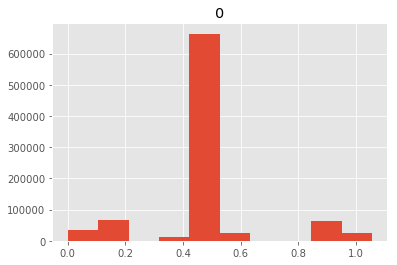

In [152]:
pos_def_const = 1-nxt2.min()
pd.DataFrame(boxcox(nxt2 + pos_def_const)[0]).hist()